In [28]:
import os, glob
import numpy as np
import pandas as pd
from PIL import Image, ImageStat
from tqdm import tqdm
import cv2
from skimage.feature import local_binary_pattern
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from matplotlib.patches import Ellipse


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

### Dataset 2 AI vs Real Art

Purpose: Classification


With the rise of generative Ai and image generation, there is an ethical dilemma regarding what is AI and what is fake, especially in media. More ethical discussions will be at the end of this notebook, but we are interested in classifying labeled images here as either AI or Real.

There are two ways to go with this: flatten the image into a 1D vector and use that for features. This requires extensive PCA to reduce the number of features [1]. Another apporach is to collect features such as colorfullness, brightness, contrast, saturation, etc [2] from each image and use those features for training. Our approach will combine the two. The formulas for each of the features are provided in [2].

### Dataset Exploration + Feature Extraction

In [ ]:
#Helper functions to compute image statistics and features


#
def preprocess_resize_rgb(pil_img, size=(32, 32)):
    # Convert to RGB and resize consistently
    img = pil_img
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[-1])
        img = bg
    elif img.mode != "RGB":
        img = img.convert("RGB")
    img = img.resize(size, Image.BILINEAR)
    return np.array(img).astype(np.uint8)  # (H,W,3)


def colorfulness_hasler(rgb_uint8):
    img = rgb_uint8.astype(np.float32)
    R, G, B = img[...,0], img[...,1], img[...,2]
    rg = R - G
    yb = 0.5*(R + G) - B
    return float(np.sqrt(rg.var() + yb.var()) + 0.3*np.sqrt(rg.mean()**2 + yb.mean()**2))

def extract_feature_vector(pil_img, size=(32, 32)):
    rgb = preprocess_resize_rgb(pil_img, size=size)  # uint8
    H, W = rgb.shape[:2]

    # Flattened pixels
    pixels = (rgb.astype(np.float32) / 255.0).reshape(-1)  # length = H*W*3

    # Channel stats
    R = rgb[...,0].astype(np.float32)
    G = rgb[...,1].astype(np.float32)
    B = rgb[...,2].astype(np.float32)

    r_mean, r_std = float(R.mean()), float(R.std())
    g_mean, g_std = float(G.mean()), float(G.std())
    b_mean, b_std = float(B.mean()), float(B.std())

    # Grayscale-based metrics 
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gray_f = gray.astype(np.float32)

    brightness = float(gray_f.mean())
    contrast_std = float(gray_f.std())

    # Sharpness: variance of Laplacian
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    sharpness = float(lap.var())

    # Saturation: mean S channel in HSV (0..1)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    saturation = float(hsv[...,1].mean() / 255.0)

    # Edge density: Canny edge proportion
    edges = cv2.Canny(gray, 100, 200)
    edge_density = float((edges > 0).mean())

    # Granularity: variance of grayscale intensities
    granularity = float(gray_f.var())

    # Gradient: mean gradient magnitude (Sobel)
    gx = cv2.Sobel(gray_f, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_f, cv2.CV_32F, 0, 1, ksize=3)
    gradient = float(np.sqrt(gx*gx + gy*gy).mean())

    # Complexity: LBP mean (simple) — upgradeable to histogram later
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    complexity = float(lbp.mean())

    # Colorfulness
    colorfulness = colorfulness_hasler(rgb)

    # Assemble all non-pixel features
    extra = np.array([
        r_mean, r_std, g_mean, g_std, b_mean, b_std,
        brightness, colorfulness, contrast_std, sharpness, saturation,
        edge_density, granularity, gradient, complexity
    ], dtype=np.float32)

    # Final feature vector
    return np.concatenate([pixels, extra], axis=0)


In [3]:
ROOT = Path(".")  # set to your project folder
CLASS_DIRS = {"RealArt": 0, "AIArtData": 1}
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

SIZE = (128, 128)

X_list, y_list, paths = [], [], []
bad = []

for cname, y in CLASS_DIRS.items():
    folder = ROOT / cname
    files = [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]
    print(cname, "files:", len(files))

    for p in tqdm(files, desc=f"Features {cname}"):
        try:
            img = Image.open(p)
            img.load()
            feat = extract_feature_vector(img, size=SIZE)
            X_list.append(feat)
            y_list.append(y)
            paths.append(str(p))
        except Exception as e:
            bad.append((str(p), cname, str(e)))

X = np.vstack(X_list)
y = np.array(y_list, dtype=int)

print("X shape:", X.shape, "y shape:", y.shape, "bad:", len(bad))

RealArt files: 434


Features RealArt:  66%|██████▌   | 287/434 [00:07<00:01, 83.50it/s]c:\Users\nihal\AppData\Local\Programs\Python\Python39\lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Features RealArt: 100%|██████████| 434/434 [00:12<00:00, 34.66it/s]


AIArtData files: 539


Features AIArtData: 100%|██████████| 539/539 [00:11<00:00, 48.85it/s]


X shape: (973, 49167) y shape: (973,) bad: 0


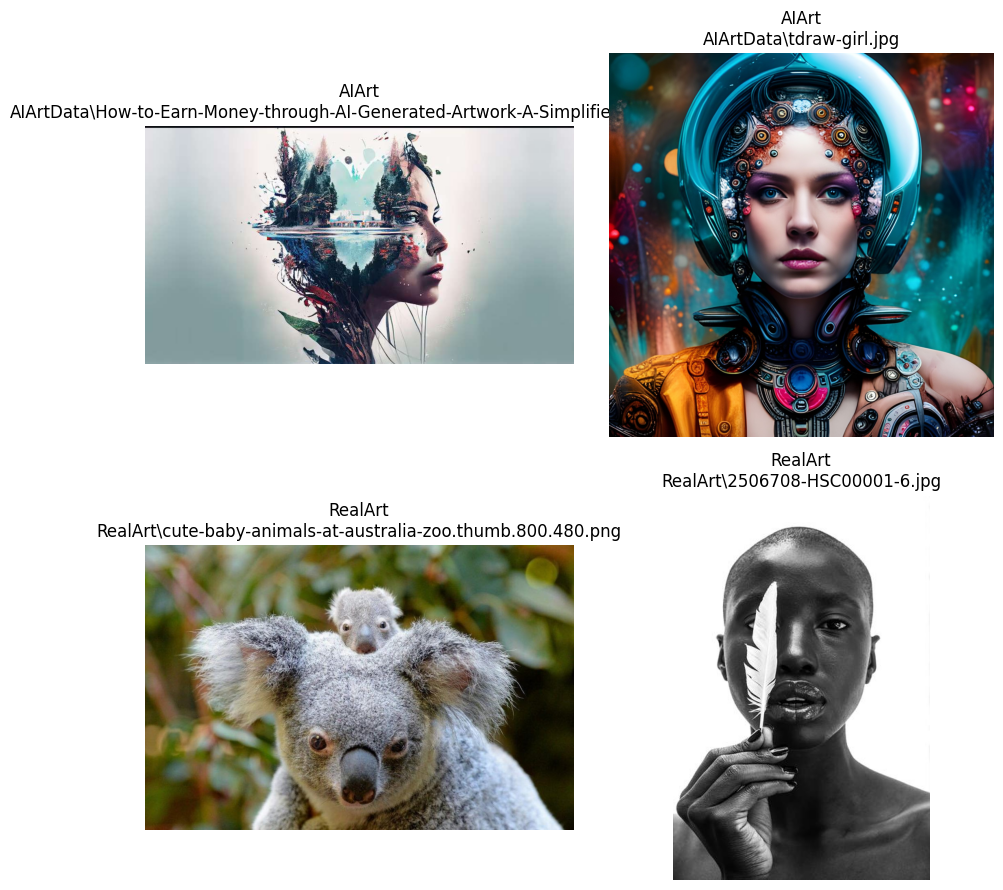

AI Art images:  539
Real Art images: 434
Prior AI Art: 0.5539568345323741
Prior Real Art: 0.4460431654676259


In [49]:
def show_2_ai_2_real(paths, y, seed=7, ai_label=1):
    rng = np.random.default_rng(seed)
    paths = np.array(paths)
    y = np.array(y).astype(int)

    ai_idx = np.where(y == ai_label)[0]
    real_idx = np.where(y != ai_label)[0]

    pick_ai = rng.choice(ai_idx, size=2, replace=False)
    pick_real = rng.choice(real_idx, size=2, replace=False)

    chosen = [("AIArt", paths[pick_ai[0]]), ("AIArt", paths[pick_ai[1]]),
              ("RealArt", paths[pick_real[0]]), ("RealArt", paths[pick_real[1]])]

    fig, axes = plt.subplots(2, 2, figsize=(9, 9))
    axes = axes.ravel()

    for ax, (label, p) in zip(axes, chosen):
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"{label}\n{p.split('/')[-1]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# call:
show_2_ai_2_real(paths, y, seed=777, ai_label=1)

Prior_AI = np.mean(y) # y==1 for AI Art
Prior_real = 1 - Prior_AI

print("AI Art images: ", np.sum(y==1))
print("Real Art images:", np.sum(y==0))
print("Prior AI Art:" , Prior_AI)
print("Prior Real Art:" , Prior_real)

We have now loaded the entire imaging dataset. Below are the priors. It is to note that we have fixed the number size of the images. The dataset contains very different size and aspect ratios. Limiting to 128 x 128 helps with computational efficiency as well as generalization (we wanted the flattened image vectors to be the same length).

Flattened pixel features shape: (973, 49152)


,r_mean,r_std,g_mean,g_std,b_mean,b_std,brightness,colorfulness,contrast,sharpness,saturation,edge_density,granularity,gradient,complexity,label,class
0,171.756653,52.222389,150.232727,57.294586,140.868408,60.240284,155.614197,53.757385,53.440948,788.593872,0.244071,0.139893,2855.934814,89.968018,4.895508,0,RealArt
1,124.274292,51.116718,121.252014,44.200874,112.448181,58.924099,121.161987,66.111763,42.897621,1301.479370,0.399854,0.167542,1840.206055,94.918701,4.748840,0,RealArt
2,61.266541,58.051163,78.716980,56.928326,66.789124,43.758278,72.142395,54.850258,52.296574,303.327362,0.513227,0.055603,2734.931641,48.569355,4.834839,0,RealArt
3,104.208252,53.214725,104.971436,54.716431,73.049927,66.421158,101.091064,55.547344,53.463696,1792.417603,0.409370,0.212830,2858.366699,133.741074,4.506348,0,RealArt
4,147.727234,62.993359,128.256897,62.530685,119.741211,67.086906,133.103455,44.503845,61.832844,3646.765869,0.281568,0.280640,3823.300537,216.381729,4.606018,0,RealArt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,127.466431,70.489243,115.223328,56.465340,99.414673,61.748783,117.083923,85.252808,54.735195,2896.077637,0.461039,0.260010,2995.941406,150.026352,4.578064,1,AIArt
969,126.171265,56.563339,120.579468,61.852188,108.701843,59.180470,120.898438,78.906212,53.060173,2923.733154,0.447841,0.270752,2815.381836,123.701630,4.710449,1,AIArt
970,91.519043,66.587425,81.830505,62.481995,75.867615,63.636986,84.049438,40.703529,62.535549,945.765320,0.351759,0.165466,3910.694824,93.931641,4.496216,1,AIArt
971,122.201111,73.628502,125.588623,55.138000,80.915527,34.664505,119.481812,63.253036,56.746071,866.855408,0.444373,0.147095,3220.116699,88.078331,4.621155,1,AIArt


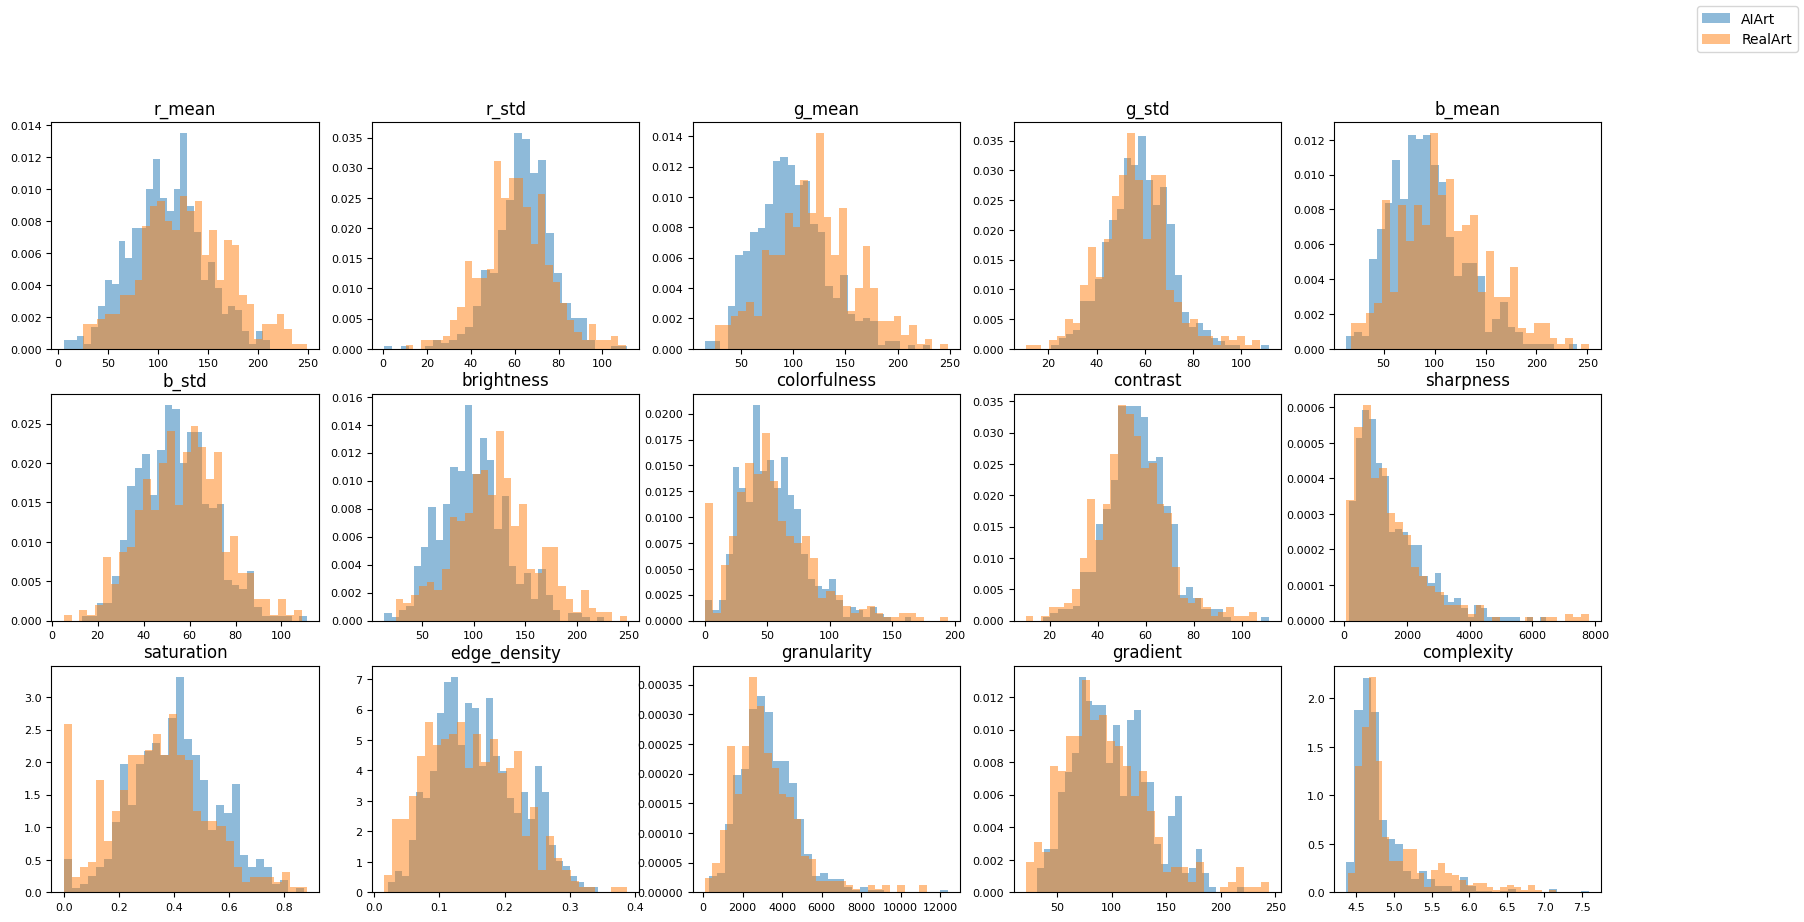

In [ ]:
#computed features
RAW_FEATURE_NAMES = [
    "r_mean", "r_std",
    "g_mean", "g_std",
    "b_mean", "b_std",
    "brightness",
    "colorfulness",
    "contrast",
    "sharpness",
    "saturation",
    "edge_density",
    "granularity",
    "gradient",
    "complexity"
]
X_flattened  = X[:, :-15]   # (N, 196608)
print("Flattened pixel features shape:", X_flattened.shape)

raw_feats = X[:, -15:]  # last 15 columns
df_feats = pd.DataFrame(raw_feats, columns=RAW_FEATURE_NAMES)
df_feats["label"] = y  # 0 = RealArt, 1 = AIArt
df_feats["class"] = df_feats["label"].map({0: "RealArt", 1: "AIArt"})

display(df_feats)

features = RAW_FEATURE_NAMES
n_feats = len(features)
n_cols = 5
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for cname, grp in df_feats.groupby("class"):
        ax.hist(
            grp[feat],
            bins=30,
            alpha=0.5,
            density=True,
            label=cname
        )
    ax.set_title(feat)
    ax.tick_params(axis='both', labelsize=8)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")


We see very clean distributions of the data here. Notably, we see that for both AI and Real Art classes, features such as color channel means and std, as well as brightness, saturation, and contrast follow gaussian distributions. We also see some trends where features such as granularity, complexity, colorfullnessnd sharpness are right skewed.

Moreover, we also see some differences in the behaviors of AI and Real Art. We see tha AI art and Real art have different green means and blue means whereas their standard deviations are comparable. Moreover, we see that there are more real_art images with lower saturation than AI images. We see many outliers as Saturation = 0 for Real Art.

The skewed features can be made normally distributed by perfoming log(skewed features). However, before that we want to see the correlation of the variables. 

Key takeway:

As we see differences in distributions of these features across the two classes: AI Art and Real Art, it is enough evidence that a baseline machine learning algorithm only on those features would suffice.

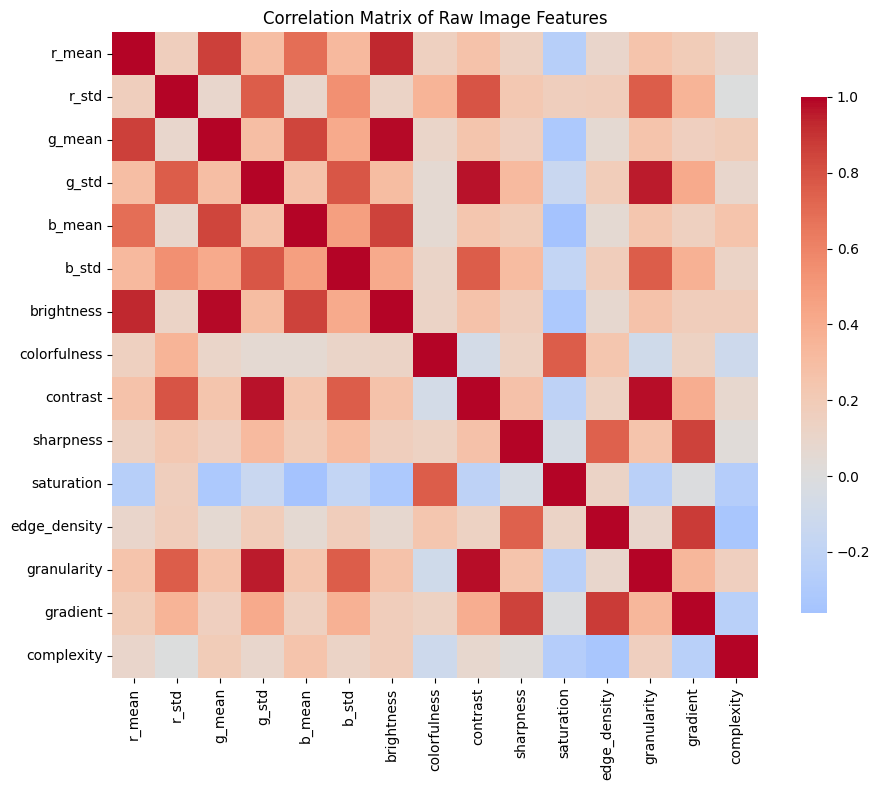

In [6]:
corr = df_feats[RAW_FEATURE_NAMES].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Raw Image Features")
plt.tight_layout()
plt.show()


From the correlation heatmap, we can see that the features relating to color channel means and standard deviations are closely related. However, we also see unexpected outcomes such as green standard deviation and granularity are closely correlated. Similarly, green standard deviation is lso strongly pairwise correlated with contrast and granularity.

Although this suffices the dropping of one of these features, we will keep them anyway. The dataset is small (973 images) and we are going to use only 15 features for baseline performance, we can keep all of these features. 

Moreover, the skewed features such as complexity and granularity, we can apply log(1+p) to make them lognormal. We use log(1+p) prevent errors with log(0).

In [ ]:
#taking logs of skewed features

skewed_features = ['edge_density','granularity', 'gradient', 'complexity', 'colorfulness', 'sharpness']
df_feats_feature_engineered = df_feats.copy()
for feat in skewed_features:
    df_feats_feature_engineered[feat] = np.log1p(df_feats[feat])

display(df_feats_feature_engineered.head())


# Final feature vector for baseline algorithms

,r_mean,r_std,g_mean,g_std,b_mean,b_std,brightness,colorfulness,contrast,sharpness,saturation,edge_density,granularity,gradient,complexity,label,class
0,171.756653,52.222389,150.232727,57.294586,140.868408,60.240284,155.614197,4.002912,53.440948,6.671519,0.244071,0.130934,7.957505,4.510508,1.774191,0,RealArt
1,124.274292,51.116718,121.252014,44.200874,112.448181,58.924099,121.161987,4.206359,42.897621,7.172025,0.399854,0.154900,7.518176,4.563501,1.748998,0,RealArt
2,61.266541,58.051163,78.716980,56.928326,66.789124,43.758278,72.142395,4.022674,52.296574,5.718104,0.513227,0.054112,7.914227,3.903373,1.763847,0,RealArt
3,104.208252,53.214725,104.971436,54.716431,73.049927,66.421158,101.091064,4.035078,53.463696,7.491879,0.409370,0.192956,7.958355,4.903355,1.705902,0,RealArt
4,147.727234,62.993359,128.256897,62.530685,119.741211,67.086906,133.103455,3.817797,61.832844,8.201870,0.281568,0.247360,8.249131,5.381655,1.723841,0,RealArt


In [8]:
X = df_feats_feature_engineered.drop(columns=["label", "class"]).values
y = df_feats_feature_engineered["label"].values
print("Final X shape:", X.shape, "y shape:", y.shape)

print(X_flattened.shape, X.shape, y.shape)


pixel_cols = [f"px_{i}" for i in range(X_flattened.shape[1])]
final_cols = pixel_cols + RAW_FEATURE_NAMES + ["label"]

df_out = pd.DataFrame(
    np.hstack([X_flattened, X, y.reshape(-1,1)]),
    columns=final_cols
)


Final X shape: (973, 15) y shape: (973,)
(973, 49152) (973, 15) (973,)


### More Data Exploration (Validating QDA and KNN)

As we saw Gaussian distributions of features, one thing that makes sene is to use LDA/QDA. With only p=15 features, we only need to learn O(p^2) features. However, we need to justify whether QDA or LDA is appropriate. Therefore, covariance matrices can be derived for each class and we can plot their ellipses onto 2 PCA component space. This will allow us to visualize if the covariances of the class are similar or not.

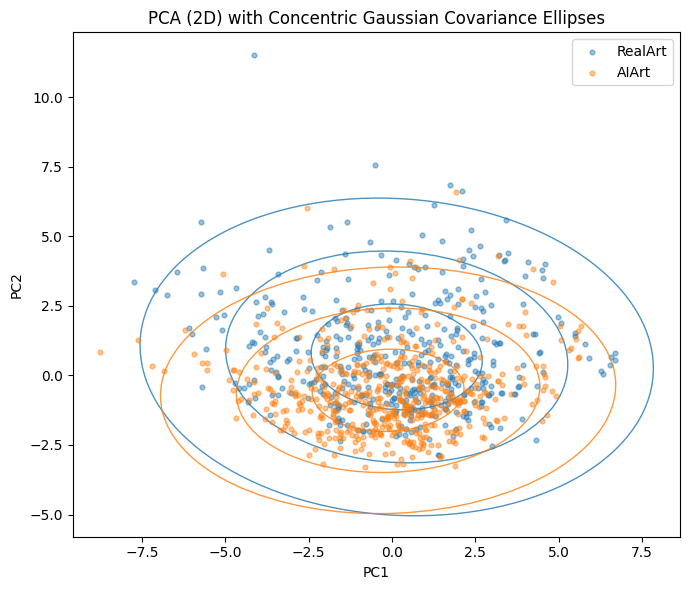

In [ ]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xz)   # shape (n_samples, 2)

def plot_cov_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    # cov is 2x2
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(7, 6))

classes = {0: "RealArt", 1: "AIArt"}
colors  = {0: "tab:blue", 1: "tab:orange"}

for cls, name in classes.items():
    Zc = Z[y == cls]
    ax.scatter(Zc[:, 0], Zc[:, 1], s=12, alpha=0.45,
               label=name, color=colors[cls])

    mu = Zc.mean(axis=0)
    cov = np.cov(Zc.T)

    # Draw multiple concentric ellipses
    for n_std in [1, 2, 3]:
        plot_cov_ellipse(
            mu, cov, ax,
            n_std=n_std,
            edgecolor=colors[cls],
            linewidth = 1,
            alpha=0.8
        )

ax.set_title("PCA (2D) with Concentric Gaussian Covariance Ellipses")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()


Key:

As we can see, the covariance matrices are slightly of different orientation. Particularly, the ellipse associated with the Real_art is wider and slightly tilted. The one for the AI class is narrower than that of the Real Art class, as well as follows the canonical PCA axes. 

Moreover, we see that the means vectors for each class are very close to each other. 

This justifies QDA as the covariance ellipses are slightly different, but results can also be comparable to that of LDA. However, we will move ahead with QDA here.
Also, as we see from the scatter plot of the data, we see that the classes are not very linearly separable, atleast on these two PCA axes. However, we see bigger density of AI art images with associated with a lower PCA 2 component whereas higher PCA 2 vaules are more common in Real Art. 

Therefore, as the data is clearly not separable, a potential algorithm here to provide good results would be KNN. It would work well in a non-linearly separable data as well as predicitng based on the density of the samples around that image. 

### Approach 1 (only using 15 derived features)

In [ ]:
#QDA argmax computation
def fit_qda(X_train, y_train):
    """
    Fit binary QDA from scratch.
    X_train: (n, d)
    y_train: (n,) with labels {0,1}
    reg: small diagonal regularization for numerical stability
    priors: "empirical" or "uniform"
    """
    y_train = np.asarray(y_train)
    classes = np.unique(y_train)
    
    model = {"classes": classes, "params": {}}
    n_total = len(y_train)
    d = X_train.shape[1]

    for c in classes:
        Xc = X_train[y_train == c] #X values for c class
        nj = Xc.shape[0]
        mu = Xc.mean(axis=0) #mean vector for c class

        X0 = Xc - mu
        cov = (X0.T @ X0) / (nj - 1)  #p x p
        
        inv_cov = np.linalg.inv(cov)
        logdet = np.log(np.linalg.det(cov + 1e-4 * np.eye(d))) #small addition prevent singular covariance matric
        
        logprior = np.log(nj / n_total)

        model["params"][c] = {
            "mu": mu,
            "inv_cov": inv_cov,
            "logdet": logdet,
            "logprior": logprior
        }

    return model

#predict the class based which delta function the sample maximizes.
def predict_qda(model, X):
    classes = model["classes"]
    p0 = model["params"][classes[0]]
    p1 = model["params"][classes[1]]

    mu0, S0i, ld0, lp0 = p0["mu"], p0["inv_cov"], p0["logdet"], p0["logprior"]
    mu1, S1i, ld1, lp1 = p1["mu"], p1["inv_cov"], p1["logdet"], p1["logprior"]

    d0 = X - mu0
    d1 = X - mu1

    q0 = np.sum((d0 @ S0i) * d0, axis=1)
    q1 = np.sum((d1 @ S1i) * d1, axis=1)

    delta0 = -0.5*q0 - 0.5*ld0 + lp0
    delta1 = -0.5*q1 - 0.5*ld1 + lp1

    return np.where(delta1 > delta0, classes[1], classes[0])


K-fold approach with K = 5
1. a. QDA

In [ ]:
def kfold_qda_eval(X, y, n_splits=5, random_state=1000000000):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    metrics = {"acc": [], "prec": [], "rec": [], "f1": []}
    cms = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        Xtr, Xte = X[tr_idx], X[te_idx]
        ytr, yte = y[tr_idx], y[te_idx]

        # scale within fold (no leakage)
        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xte_s = scaler.transform(Xte)

        # fit QDA
        model = fit_qda(Xtr_s, ytr)
        yhat = predict_qda(model, Xte_s)

        metrics["acc"].append(accuracy_score(yte, yhat))
        metrics["prec"].append(precision_score(yte, yhat))
        metrics["rec"].append(recall_score(yte, yhat))
        metrics["f1"].append(f1_score(yte, yhat))
        cms.append(confusion_matrix(yte, yhat))

        print(f"Fold {fold}: acc={metrics['acc'][-1]:.3f}, f1={metrics['f1'][-1]:.3f}")

    # summarize
    summary = {k: np.mean(v) for k, v in metrics.items()}
    return summary, cms

summary, cms = kfold_qda_eval(X, y, n_splits=5)
print("accuracy =", summary['acc'])
print("precision =", summary['prec'])
print("recall =", summary['rec'])
print("F1 score =", summary['f1'])

Fold 1: acc=0.626, f1=0.736
Fold 2: acc=0.651, f1=0.728
Fold 3: acc=0.662, f1=0.742
Fold 4: acc=0.644, f1=0.740
Fold 5: acc=0.665, f1=0.741
accuracy = 0.6495479777954004
precision = 0.6313780146158054
recall = 0.8887331256490135
F1 score = 0.7374616183891909


1. b. KNN (K-fold cross validation)

In [ ]:
def knn_predict(X_train, y_train, X_test, k):
    preds = np.empty(X_test.shape[0], dtype=int)
    for i, x in enumerate(X_test):
        dists = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
        idx = np.argpartition(dists, k)[:k]
        votes = y_train[idx]
        preds[i] = np.argmax(np.bincount(votes, minlength=2))

    return preds

def make_folds(y, K=5, random_state=42):
    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=random_state)
    dummyX = np.zeros((len(y), 1))
    folds = []
    for _, idx in skf.split(dummyX, y):
        folds.append(idx)
    return folds

def nested_kfold_knn(X, y, k_list, K=5, random_state=42):
    folds = make_folds(y, K=K, random_state=random_state)
    n = len(y)
    all_idx = np.arange(n)

    outer_test_errors = []
    chosen_ks = []

    # to plot average inner train/val error vs k across outer loops
    inner_train_err_accum = np.zeros(len(k_list), dtype=float)
    inner_val_err_accum   = np.zeros(len(k_list), dtype=float)
    inner_counts = 0

    for outer_test_i in range(K):
        test_idx = folds[outer_test_i]
        pool_idx = np.setdiff1d(all_idx, test_idx)  # K-1 folds pool (train+val)

        # Inner loop choose best k using validation folds within pool
        inner_val_err_by_k = []
        inner_train_err_by_k = []

        # Precompute the pool folds: all folds except the outer test fold
        pool_folds = [folds[j] for j in range(K) if j != outer_test_i]

        for k in k_list:
            fold_train_errs = []
            fold_val_errs = []

            # Each inner iteration: 1 fold = validation, remaining K-2 folds = training
            for val_fold_idx in pool_folds:
                val_idx = val_fold_idx
                train_idx = np.setdiff1d(pool_idx, val_idx)

                Xtr, ytr = X[train_idx], y[train_idx]
                Xval, yval = X[val_idx], y[val_idx]

                # scale using INNER training only
                scaler = StandardScaler()
                Xtr_s = scaler.fit_transform(Xtr)
                Xval_s = scaler.transform(Xval)

                # train error (on inner training)
                ytr_hat = knn_predict(Xtr_s, ytr, Xtr_s, k)
                fold_train_errs.append(np.mean(ytr_hat != ytr))

                # validation error
                yval_hat = knn_predict(Xtr_s, ytr, Xval_s, k)
                fold_val_errs.append(np.mean(yval_hat != yval))

            inner_train_err_by_k.append(np.mean(fold_train_errs))
            inner_val_err_by_k.append(np.mean(fold_val_errs))

        inner_train_err_by_k = np.array(inner_train_err_by_k)
        inner_val_err_by_k = np.array(inner_val_err_by_k)

        # Accumulate for plotting across outer loops
        inner_train_err_accum += inner_train_err_by_k
        inner_val_err_accum   += inner_val_err_by_k
        inner_counts += 1

        # pick k with minimum inner validation error (tie-break: choose larger k)
        min_err = inner_val_err_by_k.min()
        best_ks = [k for k, e in zip(k_list, inner_val_err_by_k) if np.isclose(e, min_err)]
        best_k = max(best_ks)
        chosen_ks.append(best_k)

        # Run Knn on K-1 folds and test on outer test fold 
        Xpool, ypool = X[pool_idx], y[pool_idx]
        Xte, yte = X[test_idx], y[test_idx]

        scaler = StandardScaler()
        Xpool_s = scaler.fit_transform(Xpool)
        Xte_s = scaler.transform(Xte)

        yte_hat = knn_predict(Xpool_s, ypool, Xte_s, best_k)
        test_err = np.mean(yte_hat != yte)
        outer_test_errors.append(test_err)
        recall = np.sum((yte_hat == 1) & (yte ==1)) / (np.sum(yte == 1)) 

        print(f"Outer fold {outer_test_i+1}/{K}: best_k={best_k}, test_err={test_err:.3f}, recall = {recall:3f}", )

    # Average inner curves over outer loops (for your plot)
    avg_inner_train_err = inner_train_err_accum / inner_counts
    avg_inner_val_err   = inner_val_err_accum / inner_counts

    results = {
        "outer_test_error_mean": float(np.mean(outer_test_errors)),
        "outer_test_errors": outer_test_errors,
        "chosen_ks": chosen_ks,
        "avg_inner_train_err": avg_inner_train_err,
        "avg_inner_val_err": avg_inner_val_err,
    }
    return results


Outer fold 1/5: best_k=11, test_err=0.364, recall = 0.740741
Outer fold 2/5: best_k=11, test_err=0.297, recall = 0.814815
Outer fold 3/5: best_k=13, test_err=0.344, recall = 0.740741
Outer fold 4/5: best_k=13, test_err=0.387, recall = 0.747664
Outer fold 5/5: best_k=19, test_err=0.320, recall = 0.833333

FINAL (Outer) Test Error:
Mean: 0.3422627544277029
Chosen k per outer fold: [np.int64(11), np.int64(11), np.int64(13), np.int64(13), np.int64(19)]


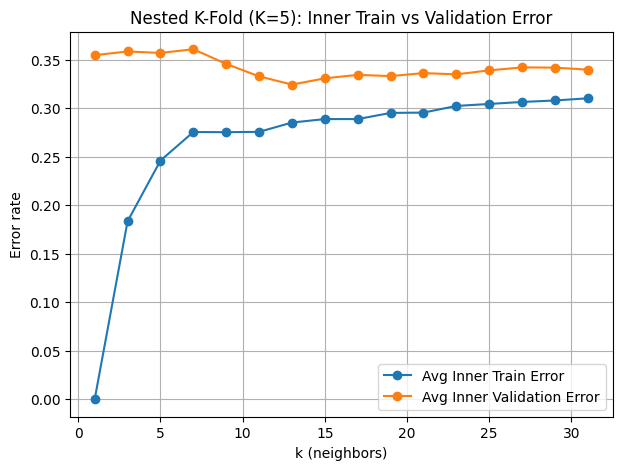

In [ ]:
k_list_approach1 = np.arange(1, 32, 2)  # odd k from 1 to 31

res = nested_kfold_knn(X, y, k_list=k_list_approach1, K=5, random_state=1)

print("\nFINAL (Outer) Test Error:")
print("Mean:", res["outer_test_error_mean"])

print("Chosen k per outer fold:", res["chosen_ks"])

plt.figure(figsize=(7,5))
plt.plot(k_list_approach1, res["avg_inner_train_err"], marker='o', label="Avg Inner Train Error")
plt.plot(k_list_approach1, res["avg_inner_val_err"], marker='o', label="Avg Inner Validation Error")
plt.xlabel("k (neighbors)")
plt.ylabel("Error rate")
plt.title("Nested K-Fold (K=5): Inner Train vs Validation Error")
plt.legend()
plt.grid(True)
plt.show()


In [48]:
avg_recall = (0.740741 + 0.814815 + 0.740741 + 0.747664 + 0.833333) / 5
print("Average Recall for KNN = ", avg_recall)

Average Recall for KNN =  0.7754588


### Approach 2

Using the entire flattened vector and derived features

In [13]:
#This is the actual full (973, 196623) dataset

X_all = df_out.drop(columns=["label"]).values
y_all = df_out["label"].values 
print(X_all.shape, y_all.shape)

(973, 49167) (973,)


As we have 49167 columns here (128 x 128 x 3 + 15), it is not good to train the model using this raw columns. We must reduce the dimensionality to do QDA and KNN. 

In [46]:
#this method performs scaling and PCA on trained dataset which is then used to fit the transformation onto Validation and test data

def do_pca(X_train, X_other_list, var_keep=0.90, random_state=42):
    """
    Fits StandardScaler + PCA on X_train, transforms X_train and any other arrays in X_other_list.
    Returns: X_train_pca, [X_other_pca...], scaler, pca
    """
    scaler = StandardScaler()
    Xtr_s = scaler.fit_transform(X_train)

    pca = PCA(n_components=var_keep, svd_solver="full", random_state=random_state)
    Xtr_p = pca.fit_transform(Xtr_s)

    X_other_p = []
    for Xo in X_other_list:
        Xo_s = scaler.transform(Xo)
        X_other_p.append(pca.transform(Xo_s))

    return Xtr_p, X_other_p, scaler, pca

2. a. QDA

In [ ]:
def kfold_qda_eval_pca(X, y, n_splits=5, var_keep=0.90, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    metrics = {"acc": [], "prec": [], "rec": [], "f1": []}
    cms = []
    pca_dims = []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        Xtr, Xte = X[tr_idx], X[te_idx]
        ytr, yte = y[tr_idx], y[te_idx]

        # Fit scaler+PCA on TRAIN only, transform TEST
        Xtr_p, [Xte_p], _, pca = do_pca(
            Xtr, [Xte], var_keep=var_keep, random_state=random_state
        )
        pca_dims.append(Xtr_p.shape[1])

        model = fit_qda(Xtr_p, ytr)
        yhat = predict_qda(model, Xte_p)

        metrics["acc"].append(accuracy_score(yte, yhat))
        metrics["prec"].append(precision_score(yte, yhat, zero_division=0))
        metrics["rec"].append(recall_score(yte, yhat, zero_division=0))
        metrics["f1"].append(f1_score(yte, yhat, zero_division=0))
        cms.append(confusion_matrix(yte, yhat))

        print(f"Fold {fold}: PCA dim={Xtr_p.shape[1]}, acc={metrics['acc'][-1]:.3f}, rec={metrics['rec'][-1]:.3f}, prec={metrics['prec'][-1]:.3f}, f1={metrics['f1'][-1]:.3f}")

    summary = {k: float(np.mean(v)) for k, v in metrics.items()}

    return summary, cms

In [33]:
summary_qda, cms_qda = kfold_qda_eval_pca(X_all, y_all, n_splits=5, var_keep=0.80, random_state=1000000)
print(summary_qda)


Fold 1: PCA dim=96, acc=0.636, rec=0.880, prec=0.621, f1=0.728
Fold 2: PCA dim=91, acc=0.646, rec=0.824, prec=0.640, f1=0.721
Fold 3: PCA dim=91, acc=0.636, rec=0.843, prec=0.628, f1=0.719
Fold 4: PCA dim=95, acc=0.624, rec=0.785, prec=0.627, f1=0.697
Fold 5: PCA dim=93, acc=0.629, rec=0.731, prec=0.648, f1=0.687
{'acc': 0.6341052075072693, 'prec': 0.6326391329217623, 'rec': 0.8125649013499482, 'f1': 0.7104073336589881}


2. b. KNN

In [ ]:
def knn_k_fold_pca(
    X, y,
    k_list,
    K=5,
    var_keep=0.90,
    metric="euclidean",
    random_state=42
):
    y = np.asarray(y).astype(int)

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=random_state)
    folds = []
    dummyX = np.zeros((len(y), 1))
    for _, idx in skf.split(dummyX, y):
        folds.append(idx)

    all_idx = np.arange(len(y))

    outer_metrics = {"acc": [], "prec": [], "rec": [], "f1": []}
    cms = []
    chosen_ks = []
    pca_dims = []

    for test_fold_id in range(K):
        test_idx = folds[test_fold_id]
        pool_fold_ids = [j for j in range(K) if j != test_fold_id]

        # rotate validation fold
        val_fold_id = pool_fold_ids[test_fold_id % (K - 1)]
        val_idx = folds[val_fold_id]

        pool_idx = np.setdiff1d(all_idx, test_idx)
        train_idx = np.setdiff1d(pool_idx, val_idx)

        Xtr, ytr = X[train_idx], y[train_idx]
        Xval, yval = X[val_idx], y[val_idx]
        Xte, yte = X[test_idx], y[test_idx]

        # preprocesses train and then fit the scaling onto validation and test
        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xval_s = scaler.transform(Xval)
        Xte_s  = scaler.transform(Xte)

        pca = PCA(n_components=var_keep, svd_solver="full", random_state=random_state)
        Xtr_p = pca.fit_transform(Xtr_s)
        Xval_p = pca.transform(Xval_s)
        Xte_p  = pca.transform(Xte_s)
        pca_dims.append(Xtr_p.shape[1])

        print(f"\nOuter fold {test_fold_id+1}/{K} | Validation fold {val_fold_id+1}")
        print("k | val_acc | val_err | val_prec | val_rec | val_f1")

        best_k = None
        best_err = np.inf

        for k in k_list:
            clf = KNeighborsClassifier(n_neighbors=int(k), metric=metric)
            clf.fit(Xtr_p, ytr)
            yval_hat = clf.predict(Xval_p)

            acc = accuracy_score(yval, yval_hat)
            err = 1.0 - acc
            prec = precision_score(yval, yval_hat, zero_division=0)
            rec = recall_score(yval, yval_hat, zero_division=0)
            f1 = f1_score(yval, yval_hat, zero_division=0)

            print(f"{k:2d} | {acc:.3f}   | {err:.3f}   | {prec:.3f}    | {rec:.3f}  | {f1:.3f}")

            # choose k by minimum validation error (tie-break: larger k)
            if (err < best_err) or (np.isclose(err, best_err) and (best_k is None or k > best_k)):
                best_err = err
                best_k = int(k)

        chosen_ks.append(best_k)

        #retrain on TRAIN+VAL, evaluate on TEST
        Xtv = np.vstack([Xtr, Xval])
        ytv = np.concatenate([ytr, yval])

        scaler2 = StandardScaler()
        Xtv_s = scaler2.fit_transform(Xtv)
        Xte_s2 = scaler2.transform(Xte)

        pca2 = PCA(n_components=var_keep, svd_solver="full", random_state=random_state)
        Xtv_p = pca2.fit_transform(Xtv_s)
        Xte_p2 = pca2.transform(Xte_s2)

        clf = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
        clf.fit(Xtv_p, ytv)
        yhat = clf.predict(Xte_p2)

        outer_metrics["acc"].append(accuracy_score(yte, yhat))
        outer_metrics["prec"].append(precision_score(yte, yhat))
        outer_metrics["rec"].append(recall_score(yte, yhat))
        outer_metrics["f1"].append(f1_score(yte, yhat))
        cms.append(confusion_matrix(yte, yhat))

        print(
            f"Fold = {test_fold_id} "
            f"Chosen k = {best_k} | "
            f"TEST acc={outer_metrics['acc'][-1]:.3f}, "
            f"prec={outer_metrics['prec'][-1]:.3f}, "
            f"rec={outer_metrics['rec'][-1]:.3f}, "
            f"f1={outer_metrics['f1'][-1]:.3f}"
        )

    summary = {m: (float(np.mean(v))) for m, v in outer_metrics.items()}
    summary["chosen_k"] = chosen_ks
    summary["pca_dim_mean"] = (float(np.mean(pca_dims)), float(np.std(pca_dims)))

    return summary, cms


In [40]:
k_list = [1, 11, 21, 31, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71] # k from odd k values

summary_knn, cms_knn = knn_k_fold_pca(X_all, y_all,k_list=k_list,K=5,var_keep=0.80,random_state=1000000
)

print("\nFINAL SUMMARY (average)")
print(summary_knn)



Outer fold 1/5 | Validation fold 2
k | val_acc | val_err | val_prec | val_rec | val_f1
 1 | 0.569   | 0.431   | 0.650    | 0.481  | 0.553
11 | 0.569   | 0.431   | 0.688    | 0.407  | 0.512
21 | 0.615   | 0.385   | 0.704    | 0.528  | 0.603
31 | 0.621   | 0.379   | 0.689    | 0.574  | 0.626
41 | 0.595   | 0.405   | 0.656    | 0.565  | 0.607
43 | 0.600   | 0.400   | 0.653    | 0.593  | 0.621
45 | 0.600   | 0.400   | 0.653    | 0.593  | 0.621
47 | 0.615   | 0.385   | 0.663    | 0.620  | 0.641
49 | 0.610   | 0.390   | 0.657    | 0.620  | 0.638
51 | 0.621   | 0.379   | 0.663    | 0.639  | 0.651
53 | 0.615   | 0.385   | 0.663    | 0.620  | 0.641
55 | 0.605   | 0.395   | 0.653    | 0.611  | 0.632
57 | 0.610   | 0.390   | 0.654    | 0.630  | 0.642
59 | 0.610   | 0.390   | 0.654    | 0.630  | 0.642
61 | 0.610   | 0.390   | 0.648    | 0.648  | 0.648
63 | 0.621   | 0.379   | 0.655    | 0.667  | 0.661
65 | 0.615   | 0.385   | 0.649    | 0.667  | 0.658
67 | 0.600   | 0.400   | 0.636    | 0.648  | 

Notes: We choose number of PCA components that are able to explain 80% of the variance in the original data. This is a hyperparameter chosen only due to the runtime of the algorithms. More explanations below under Model Evaluation.

### Model Evaluation

As we are interested in The model being able to predict AI vs Real Art, recall is the primary metric of interest. This is solely due to the ethical concerns. With the goal of differentiating between AI vs Real Art, there are bigger consequences in classifying an AI artwork as Real than a Real Artwork as AI. Therefore, we will be using Recall to judge the performance of each method.

The Results for each method over 5-Fold are given here below:

Approach 1 (only using derived features):

a. QDA: recall = 0.8887331256490135

b. KNN: recall = 0.7754588

Approach 2 (using flattened image + derived features):

a. QDA: recall = 0.8125649013499482

b. KNN: recall = 0.5659743856005538

We can see that in both approached, QDA performs better in terms of the recall. Moroever, it also performs better based on the computational efficiency KNN with cross validation required O(nt * n * p * k) complexity where n = number of training samples, p = features, k = number of folds, and nt = number of test samples. Whereas QDA only requires a the time complexity of O(k * p^2) where we learn the parameters (mean vectors and Covariance matrices) and we are able to use that for all test samples. 

Moreover, for KNN for approach 1b, we see that validation error is pretty much constant. This means that the data is not lending itself to an optimal k. This is evident as even with 5-folds, we many different best k values in each fold (11, 11, 13, 13 19). Although these are close, any k around 13 seems optimal, the curve sugggests very small difference in average validation error across each k. 

Peculiarly, we see that the addition of the flattened image provides no benefit to the classifier, it actually makes the classifier worse for both QDA and KNN. This is due to the fact that the Art images are very different from one another(some are animals, humans, but we alo have scenery, etc.) A better thing would be to do is utilize transfer learning. Using pre-trained CNN models to provide us features of interest which we can then use to train a classical machine learning classifier. 

However, over here we achieve an 88% TPR using only 15 features derived from the images. With a bigger dataset and more features this can be made into a much better and robust classifier.

### Ethical Discussions
AI generated imagery poses a real challenge to many today. Within only a few years, AI generated images have progressed from a compiled and convoluted mess to actually being believable. The amount of details in the images have increased whereas they wereflat beforehand, and as the consequence of being trained on larger data, AI images almost mimic real-world art and imagery [3]. 

Although AI images can be harmless when they are restrained to producing stock-like imagery and aiding in creative processes, the actual harm lies with fake news and deepfakes. Although these lend themselves with video media, but it can be generalized to any AI imagery. Parra and Stroud state that AI imagery has led to a reduced trust in news media and are often the proponents of providing misleading information that works to aggrevate the audience [4]. Therefore, a classifier like this is very much need which can determine if an image is AI but with a better accuracy. 

The low accuracy currently leads to some ethical issues. First of all, if a classifer like this is deployed for the use of general public, they may believe an image of Real Art given the classifier output even though it may be an AI image. However, the bigger concern is the situation where an AI image is classified as Real and taken as the truth by the user. Due to these concerns, the classifier needs to be flushed out more by either: getting more data and using more industry standard methods (using CNNs).

### Bibliography

- [1] https://www.geeksforgeeks.org/machine-learning/impact-of-image-flattening/
- [2] https://www.sciencedirect.com/science/article/pii/S0306457325001591
- [3] https://medium.com/@junehao/comparing-ai-generated-images-two-years-apart-2022-vs-2024-6c3c4670b905
- [4] https://mediaengagement.org/research/the-ethics-of-ai-art/
